# Task 2: Decision Trees for Classification


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Load the dataset


In [2]:

df = pd.read_csv("dataset/iris.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Inspect the data

Before training, check the column types, missing values, and class distribution.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
print("Missing values per column:")
print(df.isna().sum())

print("\nClass distribution:")
print(df["species"].value_counts())

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 4. Prepare features and target

`X` contains the input features.  
`y` contains the class label we want to predict.

In [5]:
X = df.drop(columns=["species"])
y = df["species"]

print("Feature columns:", X.columns.tolist())
print("Target column: species")

Feature columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Target column: species


## 5. Split into training and testing data

We train on 80% of the data and test on 20%.

`stratify=y` keeps the class distribution balanced in both sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 120
Testing rows: 30


## 6. Train the decision tree



In [7]:
basic_tree = DecisionTreeClassifier(
    random_state=42
)

basic_tree.fit(X_train, y_train)

basic_train_accuracy = basic_tree.score(X_train, y_train)
basic_test_accuracy = basic_tree.score(X_test, y_test)

print("Basic tree training accuracy:", round(basic_train_accuracy, 4))
print("Basic tree testing accuracy:", round(basic_test_accuracy, 4))

Basic tree training accuracy: 1.0
Basic tree testing accuracy: 0.9333


## 7. Train a pruned decision tree

Pruning helps reduce overfitting.

Here we limit the tree using:

- `max_depth=3`
- `min_samples_leaf=2`

In [8]:
pruned_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=2,
    random_state=42
)

pruned_tree.fit(X_train, y_train)

pruned_train_accuracy = pruned_tree.score(X_train, y_train)
pruned_test_accuracy = pruned_tree.score(X_test, y_test)

print("Pruned tree training accuracy:", round(pruned_train_accuracy, 4))
print("Pruned tree testing accuracy:", round(pruned_test_accuracy, 4))

Pruned tree training accuracy: 0.9833
Pruned tree testing accuracy: 0.9667


## 8. Evaluate the pruned model

I will use:

- **Accuracy:** percentage of correct predictions.
- **F1-score:** balance between precision and recall.
- **Classification report:** detailed metrics per class.

In [9]:
y_pred = pruned_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", round(accuracy, 4))
print("Macro F1-score:", round(macro_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9667
Macro F1-score: 0.9666

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 9. Visualize the confusion matrix

The confusion matrix shows correct and incorrect predictions for each class.

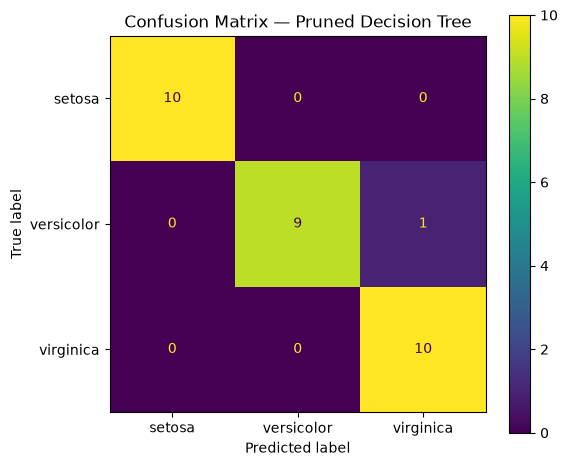

Saved to: outputs\confusion_matrix.png


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_estimator(
    pruned_tree,
    X_test,
    y_test,
    ax=ax,
    values_format="d"
)

plt.title("Confusion Matrix — Pruned Decision Tree")
plt.tight_layout()

confusion_matrix_path = OUTPUT_DIR / "confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=200)
plt.show()

print("Saved to:", confusion_matrix_path)

## 10. Visualize the decision tree

This diagram shows how the model makes decisions.

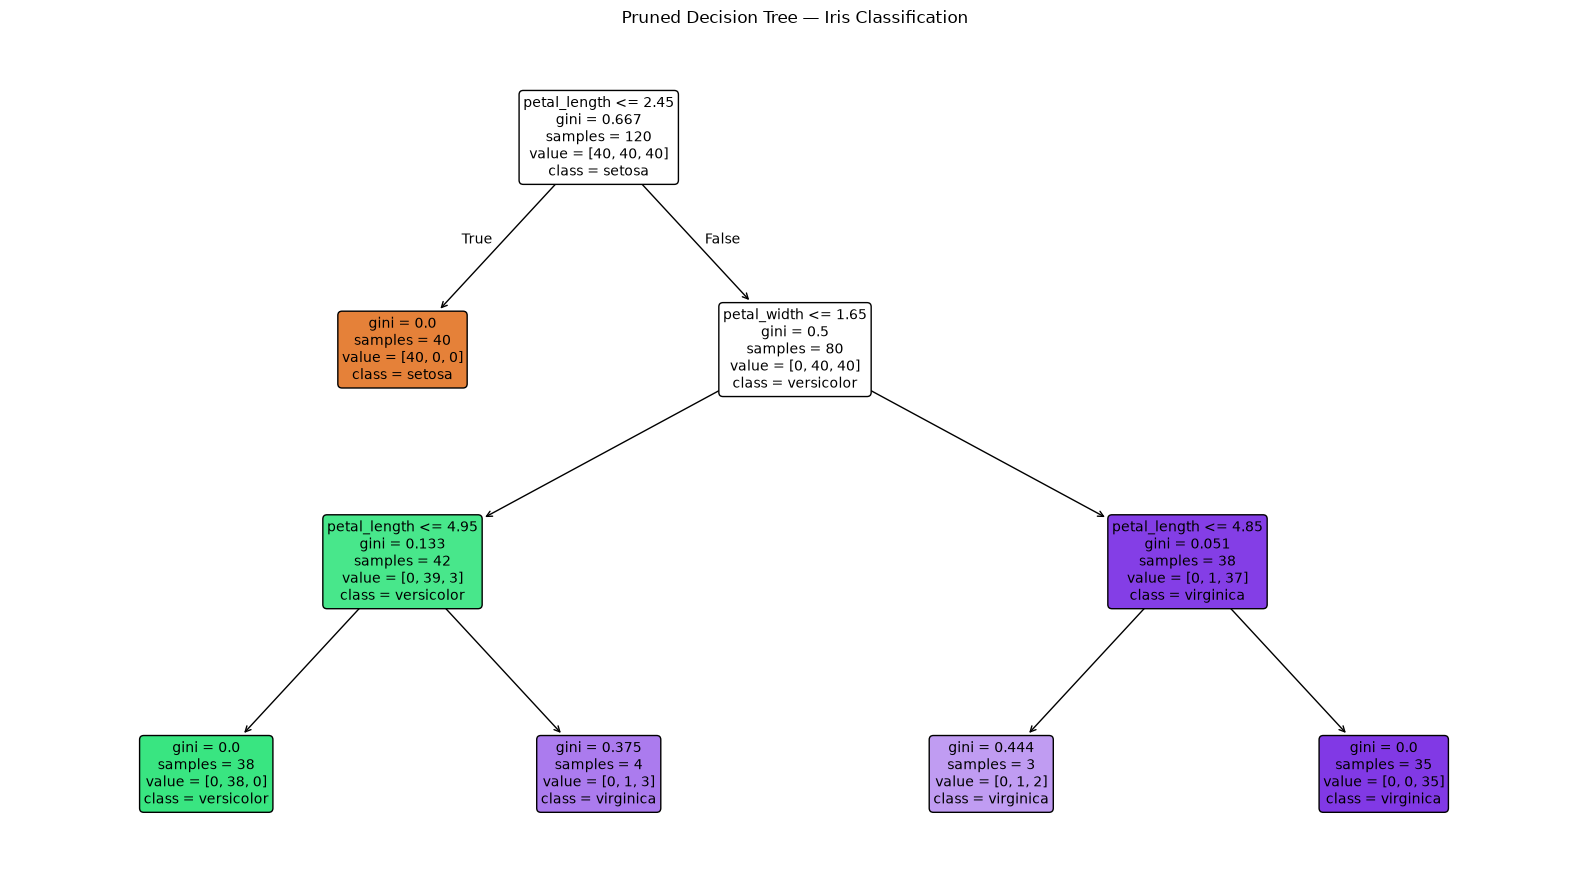

Saved to: outputs\pruned_decision_tree.png


In [11]:
fig, ax = plt.subplots(figsize=(16, 9))

plot_tree(
    pruned_tree,
    feature_names=X.columns,
    class_names=pruned_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)

plt.title("Pruned Decision Tree — Iris Classification")
plt.tight_layout()

tree_path = OUTPUT_DIR / "pruned_decision_tree.png"
plt.savefig(tree_path, dpi=200)
plt.show()

print("Saved to:", tree_path)

## 11. Feature importance

Feature importance shows which input columns were most useful for the model.

In [12]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": pruned_tree.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
2,petal_length,0.579077
3,petal_width,0.420923
1,sepal_width,0.000000
0,sepal_length,0.000000


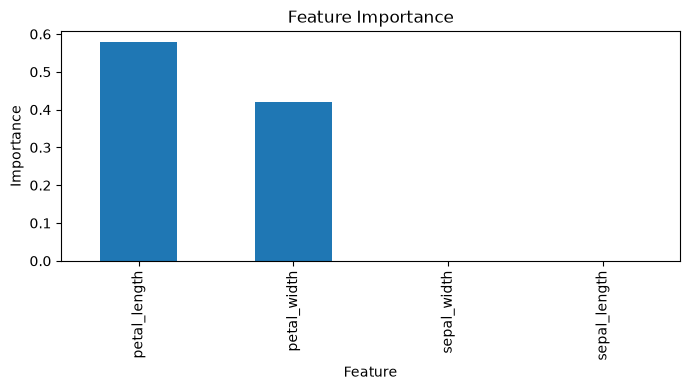

Saved to: outputs\feature_importance.png


In [13]:
ax = importance_df.plot(
    kind="bar",
    x="feature",
    y="importance",
    legend=False,
    figsize=(7, 4)
)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()

feature_importance_path = OUTPUT_DIR / "feature_importance.png"
plt.savefig(feature_importance_path, dpi=200)
plt.show()

print("Saved to:", feature_importance_path)

## Final summary

In this project, I successfully:

- loaded a labeled classification dataset,
- trained a decision tree classifier,
- applied simple pruning,
- evaluated the model using accuracy and F1-score,
- visualized the confusion matrix,
- visualized the decision tree structure
